# Lecture 11b — The four assumptions of linear regression

`lec_11a` fit a one-feature OLS three different ways and got identical numbers from statsmodels, pingouin, and scikit-learn.
The math is settled. The next question is: **when is OLS the *right* tool**, and **what can go wrong** if it is not?

OLS produces unbiased coefficients and trustworthy standard errors **only when four assumptions hold**.
This notebook names them, shows them satisfied and violated on synthetic data, demonstrates the checks on `grades_factors`, and points to the fix for each.

## The four classical assumptions

1. **Linearity** — `y ≈ β₀ + β₁ x₁ + … + β_p x_p` (linear in the parameters).
2. **Independence of errors** — each observation's error is uncorrelated with the others (no autocorrelation).
3. **Homoscedasticity** — errors have constant variance across the range of `ŷ`.
4. **Normality of errors** — errors are normally distributed.

The first three matter for both *prediction* and *inference*.
The fourth matters mostly for **inference** — p-values, confidence intervals, and t-statistics from a `.summary()` table are only trustworthy when residuals are roughly normal.
For pure prediction (the use case from `lec_11c` onwards) normality matters far less.

## Two industry uses that turn on these assumptions

- **Insurance pricing models.** Coefficients on age, vehicle type, and claim history go into a public-facing premium formula. Regulators routinely audit these fits. Violating linearity (premium grows faster than linearly above 75) or heteroscedasticity (claim-amount spread grows with age) silently breaks the inference and exposes the company to legal risk. Residual diagnostics are not optional.
- **Clinical trial dose-response.** Estimating how a measured outcome (blood pressure, tumour size) changes with drug dose. If the relationship is nonlinear, forcing a straight line gives a confidence interval that excludes the true effect; the trial conclusion can flip on this misspecification. Polynomial features, transformations, or generalised additive models are the principled responses.

Both are **inference** workflows where assumption violations bite — which is why the assumption-checking culture is strongest in the regulated industries.

## How this notebook is organised

1. Setup.
2. **Assumption 1 — Linearity.** What it means, what violation looks like, how to spot it, what to do.
3. **Assumption 2 — Independence.** Why this matters mostly for time-series and clustered data.
4. **Assumption 3 — Homoscedasticity.** The fan-shape signal, formal and informal tests, the fixes.
5. **Assumption 4 — Normality of errors.** The QQ plot reflex, when it matters, when it does not.
6. **Putting it together** — run all four checks on `grades_factors`.
7. **Reference table** — symptom on the left, fix on the right.

We use **scikit-learn** for the OLS fits and **scipy.stats** for the QQ plot — consistent with the "scikit-learn from here on" convention set in `lec_11a §7`.


## §B. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from scipy import stats
import pingouin as pg

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

sns.set_theme(style="whitegrid")


def fit_and_residuals(X, y):
    """Helper: fit OLS, return fitted values and residuals."""
    model = LinearRegression().fit(X, y)
    y_hat = model.predict(X)
    return model, y_hat, y - y_hat

## §C. Assumption 1 — Linearity

- **Statement.** `E[y | X] = β₀ + β₁ x₁ + … + β_p x_p` — the conditional mean of `y` is a linear function of the *parameters*. "Linear in parameters" — you can include `x²` or `log(x)` as a feature and still satisfy this assumption.
- **What violation looks like.** Fit a line to data that genuinely curves. Residuals are systematically positive in some ranges of `ŷ` and systematically negative in others — a curve or U-shape in the residuals-vs-fitted plot.
- **The check.** Residuals-vs-fitted plot. Look for *patterned* deviation from zero. Random scatter = assumption holds; visible curve or U = assumption violated.
- **The fix.** Add polynomial features (`PolynomialFeatures`, see `lec_11e`), include log or square-root transforms of features, or move to a non-linear model. Forcing a linear fit on curved data is the original sin of regression.


In [ ]:
# Synthetic data: case A truly linear, case B curved (quadratic).
n = 200
x = np.linspace(0, 10, n)

y_linear = 1.0 + 0.6 * x + 0.5 * rng.standard_normal(n)
y_curve  = 1.0 + 0.6 * x - 0.07 * x**2 + 0.5 * rng.standard_normal(n)

X = x.reshape(-1, 1)

m_A, yhat_A, res_A = fit_and_residuals(X, y_linear)
m_B, yhat_B, res_B = fit_and_residuals(X, y_curve)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].scatter(x, y_linear, alpha=0.5)
axes[0, 0].plot(x, yhat_A, color="red")
axes[0, 0].set_title("Case A — truly linear")
axes[0, 0].set_xlabel("x"); axes[0, 0].set_ylabel("y")

axes[0, 1].scatter(yhat_A, res_A, alpha=0.5)
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("Residuals vs fitted (Case A) — looks like noise")
axes[0, 1].set_xlabel("fitted y"); axes[0, 1].set_ylabel("residual")

axes[1, 0].scatter(x, y_curve, alpha=0.5)
axes[1, 0].plot(x, yhat_B, color="red")
axes[1, 0].set_title("Case B — quadratic data, linear fit")
axes[1, 0].set_xlabel("x"); axes[1, 0].set_ylabel("y")

axes[1, 1].scatter(yhat_B, res_B, alpha=0.5)
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_title("Residuals vs fitted (Case B) — visible curve = LINEARITY VIOLATED")
axes[1, 1].set_xlabel("fitted y"); axes[1, 1].set_ylabel("residual")

plt.tight_layout()
plt.show()

The Case-A scatter looks like noise — the linear fit is appropriate.  
The Case-B scatter has a clear inverted-U: residuals are negative at the extremes and positive in the middle.  
That pattern is the linearity assumption failing in plain sight; no statistical test is needed once the picture is this clean.  
The fix is in `lec_11e`'s polynomial features.


> ⏱ **Skip if running long.** §C2 below is a numerical linearity check using `pingouin`. It is a useful sanity-check pattern but not required for the rest of §C–§H, which all use scikit-learn + scipy.stats. If class time is tight, point students at the cell and move to §D.


## §C2. A numerical linearity check with pingouin

Visual inspection of the residuals-vs-fitted plot is the *first* check, and on Case B above it was already conclusive.  
Sometimes you want a single statistic to drop in a report.  
Pingouin does **not** ship a dedicated linearity test (that is statsmodels territory — Harvey–Collier and Ramsey RESET).  
It does give you a clean way to *triangulate* linearity from two correlation coefficients:

- **Pearson `r`** — measures *linear* association.
- **Spearman `ρ`** — measures *monotonic* association (rank-based, no straight-line assumption).

The diagnostic is the **gap** between them:

| Pearson vs Spearman | Interpretation |
| --- | --- |
| `|r| ≈ |ρ|` | Association is monotonic *and* linear → linearity assumption holds. |
| `|ρ| > |r|` (clearly) | Association is monotonic but **curved** → linearity is violated. Bigger gap = worse curvature. |
| `|r| > |ρ|` | Almost never happens on clean data; usually an outlier inflating Pearson. |

`pg.corr(x, y, method="pearson" | "spearman")` returns a tidy one-row DataFrame with `r`, its 95 % CI, and a p-value — exactly the format you would paste into a write-up.


In [ ]:
# Case A from §C is truly linear -- reuse its x and y_linear.
# Case C: monotonic but curved (square-root relationship) -- a textbook
#         "Spearman beats Pearson" example.
n_c = 200
x_c = np.linspace(0.1, 10, n_c)
y_exp = 1.0 + 0.5 * np.exp(0.4 * x_c) + 0.5 * rng.standard_normal(n_c)


def linearity_gap(x_arr, y_arr, label):
    pear = pg.corr(x_arr, y_arr, method="pearson").iloc[0]
    spr  = pg.corr(x_arr, y_arr, method="spearman").iloc[0]
    gap = abs(spr["r"]) - abs(pear["r"])
    verdict = (
        "LINEAR (gap ~ 0)"        if abs(gap) < 0.02
        else "CURVED (Spearman > Pearson)" if gap > 0
        else "non-monotonic or outlier-distorted (Pearson > Spearman)"
    )
    print(f"--- {label} ---")
    print(f"  Pearson  r = {pear['r']:+.4f}   95% CI = {pear['CI95']}   p = {pear['p_val']:.2e}")
    print(f"  Spearman r = {spr['r']:+.4f}   95% CI = {spr['CI95']}   p = {spr['p_val']:.2e}")
    print(f"  |Spearman| - |Pearson| = {gap:+.4f}   ->  {verdict}\n")


linearity_gap(x,   y_linear, "Case A — truly linear")
linearity_gap(x_c, y_exp,   "Case C — y = exp(0.4x), monotonic but curved")

# Sanity check: rerun on Case B (the inverted-U from §C) to expose the test's
# blind spot -- both r values are small, the gap is misleading.
linearity_gap(x, y_curve, "Case B (revisited) — inverted-U, non-monotonic")


**Reading the output.**

- **Case A** — Pearson and Spearman sit on top of each other. Gap ≈ 0 → linearity holds.
- **Case C** — Spearman is materially *larger* than Pearson. The rank-based statistic does not care that `y = exp(0.4·x)` bends; the linear-only Pearson does, and pays for it. A positive gap is the linearity violation, in a single number.
- **Case B revisited** — both correlations are small and the gap goes the *wrong* way. That is the test's blind spot: it cannot diagnose a *non-monotonic* curve (the inverted-U), because Spearman is built on monotonicity. The residuals-vs-fitted plot in §C caught Case B easily; the pingouin gap does not.

**Practical use.**

- Run the gap as a *companion number* to the residuals-vs-fitted plot, not as a replacement. Plot first; quote the gap.
- A *positive* gap is informative ("monotonic but curved → try log/sqrt/polynomial features"). A *negative* gap is a smoke alarm to go look at the plot, not a clean signal.
- This is a *univariate* diagnostic; for multiple regression, run it once per feature against `y`, and never skip the multivariate residuals-vs-fitted check (two features can each look linear marginally and still bend jointly).
- For a proper statistical test of linearity (rejecting H₀ : "the linear specification is correct"), use `statsmodels.stats.diagnostic.linear_harvey_collier` or `linear_reset`. Pingouin's strength here is tabular convenience, not specialised regression diagnostics.


## §D. Assumption 2 — Independence of errors

- **Statement.** `Cov(ε_i, ε_j) = 0` for `i ≠ j` — one observation's error tells you nothing about another's.
- **When usually satisfied.** Cross-sectional data drawn by random sampling — surveys, snapshots of unrelated entities. Most teaching datasets fall here, including `grades_factors` (each row is a different student).
- **When usually violated.** Time-series data (today's error correlates with yesterday's), clustered data (students from the same school share unobserved factors), repeated measurements on the same unit.

**The check.** For cross-sectional data:

- Order rows by *time of measurement* or *cluster id*, then plot residuals in that order. A run of positive followed by a run of negative residuals is autocorrelation.
- Numerically: lag-1 correlation of the residual sequence — `np.corrcoef(resid[:-1], resid[1:])`.
- Or the formal **Durbin–Watson** statistic — near 2.0 = no autocorrelation; below 1.5 or above 2.5 = warning sign.

**The fix.**

- *Time-series data* — add lag features (yesterday's `y` as a feature), use ARIMA / state-space models, or OLS with HAC (heteroscedasticity-and-autocorrelation-consistent) standard errors.
- *Clustered data* — cluster-robust standard errors.
- *Cross-sectional data with random sampling* — usually no action needed; the assumption holds by design.


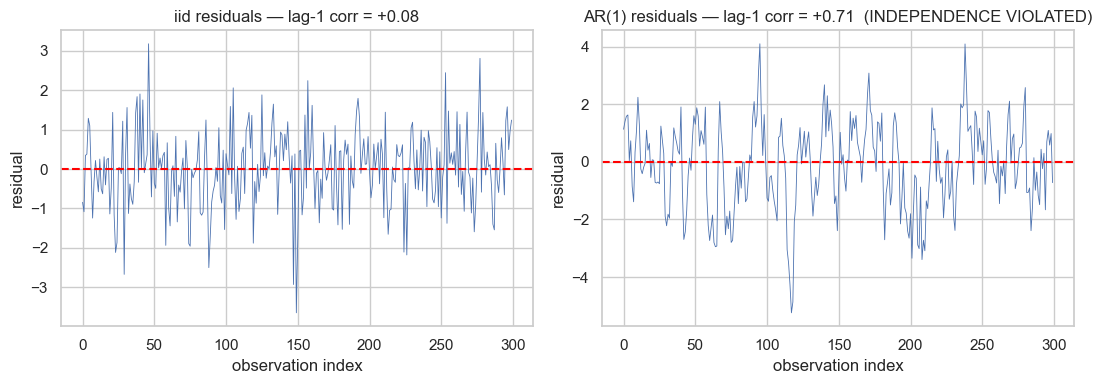

In [4]:
# Synthetic: residual sequence under iid vs AR(1) generating process.
n = 300

iid_residuals = rng.standard_normal(n)

# AR(1): each residual = phi * previous + noise; phi=0.7 is moderately autocorrelated.
phi = 0.7
ar_residuals = np.zeros(n)
ar_residuals[0] = rng.standard_normal()
for t in range(1, n):
    ar_residuals[t] = phi * ar_residuals[t - 1] + rng.standard_normal()

lag1_iid = np.corrcoef(iid_residuals[:-1], iid_residuals[1:])[0, 1]
lag1_ar  = np.corrcoef(ar_residuals[:-1],  ar_residuals[1:])[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(iid_residuals, linewidth=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title(f"iid residuals — lag-1 corr = {lag1_iid:+.2f}")
axes[0].set_xlabel("observation index"); axes[0].set_ylabel("residual")

axes[1].plot(ar_residuals, linewidth=0.6)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title(f"AR(1) residuals — lag-1 corr = {lag1_ar:+.2f}  (INDEPENDENCE VIOLATED)")
axes[1].set_xlabel("observation index"); axes[1].set_ylabel("residual")

plt.tight_layout()
plt.show()

The iid sequence (left) flips sign rapidly with no memory; the lag-1 correlation is near zero.  
The AR(1) sequence (right) has visible runs — once positive, it tends to stay positive for several steps.  
The lag-1 correlation lands near 0.7, exactly the AR coefficient we put in.  
On real data you do not know the true `φ`, but the *picture* and the *number* together are enough to spot the issue.

For `grades_factors` we have no row ordering by time and the students are drawn from a single random sample, so the independence assumption is satisfied by sampling design.


## §E. Assumption 3 — Homoscedasticity (constant error variance)

- **Statement.** `Var(ε | X) = σ²` constant — the variance of the error is the same for every value of `X` (and every fitted `ŷ`).
- **What violation looks like.** A residuals-vs-fitted plot whose *spread* grows or shrinks with `ŷ` — a "fan" or "trumpet" shape. Common when the target is right-skewed (incomes, sales counts) or when the dependent variable's scale grows with the predictors.
- **The check.** Residuals-vs-fitted plot. Formal tests exist (Breusch–Pagan, White) but visual inspection catches almost all real cases. We keep the visual check throughout this course.

**The fix — three options:**

- **Log-transform the target** — `y_log = np.log(y)` if `y` is right-skewed and strictly positive; refit on `y_log`.
- **Weighted least squares** — weights proportional to `1 / Var(ε | X)`.
- **Robust standard errors** — HC0, HC1, HC2, HC3 (statsmodels has these one flag away) so p-values stay honest even though the assumption is violated.

*The coefficients themselves are still unbiased under OLS even with heteroscedasticity* — only the standard errors are affected.


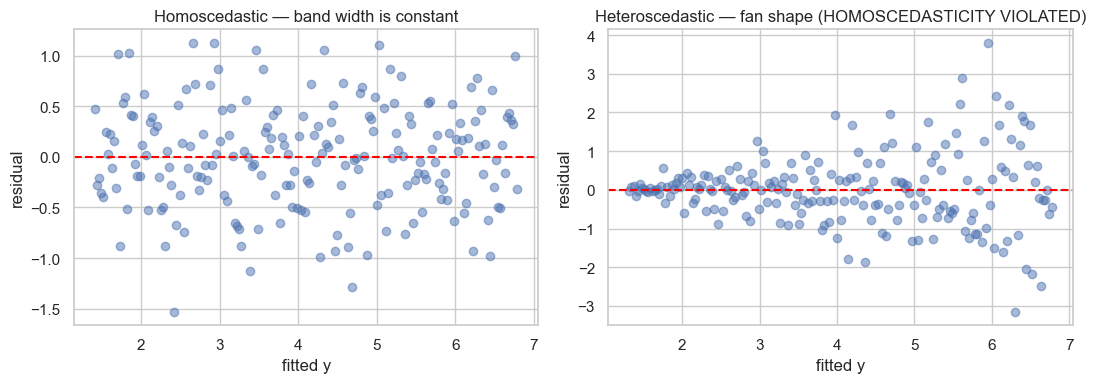

In [5]:
# Synthetic: homoscedastic vs heteroscedastic data.
n = 200
x = np.linspace(0.5, 10, n)
X = x.reshape(-1, 1)

# Homoscedastic: constant noise.
y_homo = 1.0 + 0.6 * x + 0.5 * rng.standard_normal(n)

# Heteroscedastic: noise grows linearly with x.
y_hetero = 1.0 + 0.6 * x + (0.15 * x) * rng.standard_normal(n)

m_homo,   yhat_homo,   res_homo   = fit_and_residuals(X, y_homo)
m_hetero, yhat_hetero, res_hetero = fit_and_residuals(X, y_hetero)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(yhat_homo, res_homo, alpha=0.5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Homoscedastic — band width is constant")
axes[0].set_xlabel("fitted y"); axes[0].set_ylabel("residual")

axes[1].scatter(yhat_hetero, res_hetero, alpha=0.5)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Heteroscedastic — fan shape (HOMOSCEDASTICITY VIOLATED)")
axes[1].set_xlabel("fitted y"); axes[1].set_ylabel("residual")

plt.tight_layout()
plt.show()

**Reading the two plots.**

- **Left plot** — the band of residuals is roughly the same width across `ŷ`. Homoscedasticity holds.
- **Right plot** — the band widens as `ŷ` grows; that is the fan. OLS's reported standard errors are too tight at high `ŷ` and too loose at low `ŷ`; p-values are not what they claim to be.

**Practical note.** The classic fix on right-skewed positive targets is to fit `np.log(y)` instead of `y` directly.  
Coefficients then shift to a multiplicative interpretation — *"per 1-unit change in `X`, `y` changes by roughly β·100 %"* — rather than additive.  
That is often what you want anyway when modelling prices, incomes, or counts.


## §F. Assumption 4 — Normality of errors

- **Statement.** `ε ~ N(0, σ²)` — the residuals are drawn from a normal distribution.
- **What it does and does not affect.** Normality is the *least* important of the four for prediction. The **Gauss–Markov theorem** (OLS is BLUE — Best Linear Unbiased Estimator) does **not** require normality; it requires linearity, independence, and homoscedasticity. Coefficient estimates remain unbiased and efficient under non-normal errors.
- **What normality buys you.** Valid **inference** — t-statistics, p-values, F-tests, and confidence intervals are *exact* only under normal residuals, and *approximately correct* under non-normal residuals when `n` is large (central limit theorem).
- **The check.** QQ plot of residuals against the normal distribution. Points should lie close to the diagonal. Tail departures = heavy-tailed residuals (large outliers); a curve in the middle = skewed residuals.

**The fix — depends on the cause:**

- **Heavy tails** — robust regression (`HuberRegressor`, see `lec_11f`); robust standard errors; or transform `y` if the heavy tails come from skew.
- **Skewed residuals** — log-transform `y` if it is right-skewed and positive; cube-root if it can be negative.
- **Small sample plus mild non-normality** — bootstrap the standard errors (see `lec_11d §P3`).
- **Large sample** — by the central limit theorem, the sampling distribution of the OLS coefficient is approximately normal *regardless* of residual normality; inference is fine.


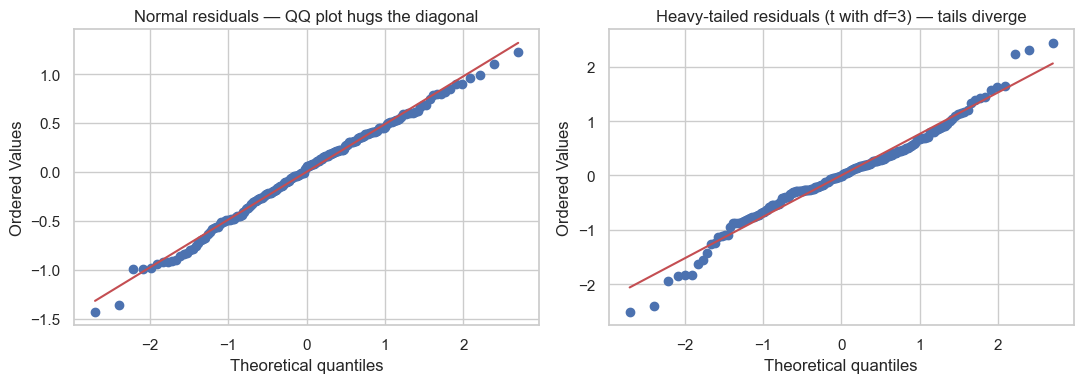

In [6]:
n = 200
x = np.linspace(0, 10, n)
X = x.reshape(-1, 1)

# Case A: normal noise.
y_normal = 1.0 + 0.6 * x + 0.5 * rng.standard_normal(n)

# Case B: heavy-tailed noise (Student-t with 3 degrees of freedom).
heavy_noise = stats.t.rvs(df=3, size=n, random_state=int(rng.integers(1_000_000)))
y_heavy = 1.0 + 0.6 * x + 0.5 * heavy_noise

_, _, res_normal = fit_and_residuals(X, y_normal)
_, _, res_heavy  = fit_and_residuals(X, y_heavy)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(res_normal, dist="norm", plot=axes[0])
axes[0].set_title("Normal residuals — QQ plot hugs the diagonal")

stats.probplot(res_heavy, dist="norm", plot=axes[1])
axes[1].set_title("Heavy-tailed residuals (t with df=3) — tails diverge")

plt.tight_layout()
plt.show()

Left QQ plot — residuals fall on the diagonal; normality holds.  
Right QQ plot — the *tails* curve away from the diagonal (negative residuals are more negative than normal predicts, positive residuals more positive).  
That is the classic heavy-tail signature.  
The middle of the distribution looks fine; it is the tails that betray it.

If the QQ plot showed a smooth *curve* rather than divergent tails, the residuals would be skewed rather than heavy-tailed, and the fix is a different one (transform the target, not switch to robust regression).


## §G. Running all four checks on `grades_factors`

Now we do the real thing: fit a multiple OLS on `grades_factors.xlsx`, then run all four assumption checks. This is the workflow you should adopt for every regression you fit from here on.


In [9]:
df = pd.read_excel("grades_factors.xlsx")
df.columns = df.columns.str.replace(" ", "_").str.lower()
df = df.drop(columns=["gender"]).rename(columns={"gender_code": "gender_male"})


In [10]:

feature_cols = ["calc_hs", "act_math", "alg_place", "alg2_grade", "hs_rank", "gender_male"]
X_g = df[feature_cols].astype(float)
y_g = df["calc"].astype(float)


In [11]:

ols_g, yhat_g, res_g = fit_and_residuals(X_g, y_g)
print(f"n = {len(df)} | Training R^2 = {ols_g.score(X_g, y_g):.3f}")

n = 80 | Training R^2 = 0.372


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# (1) Linearity / homoscedasticity — residuals vs fitted.
axes[0, 0].scatter(yhat_g, res_g, alpha=0.7)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals vs fitted  -- checks #1 (linearity) and #3 (homoscedasticity)")
axes[0, 0].set_xlabel("fitted y"); axes[0, 0].set_ylabel("residual")

# (2) Independence — residuals in row order, lag-1 correlation.
axes[0, 1].plot(res_g.values, marker="o", linewidth=0.6)
axes[0, 1].axhline(0, color="red", linestyle="--")
lag1 = np.corrcoef(res_g.values[:-1], res_g.values[1:])[0, 1]
axes[0, 1].set_title(f"Residuals in row order  --  lag-1 corr = {lag1:+.2f}")
axes[0, 1].set_xlabel("row index"); axes[0, 1].set_ylabel("residual")

# (3) Normality — QQ plot.
stats.probplot(res_g, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ plot  --  check #4 (normality of errors)")

# (4) Histogram of residuals as a second view of normality / skew.
axes[1, 1].hist(res_g, bins=15, edgecolor="white", color="#9bbcd6")
axes[1, 1].axvline(0, color="red", linestyle="--")
axes[1, 1].set_title("Residual histogram  --  centred at zero, roughly symmetric?")
axes[1, 1].set_xlabel("residual"); axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

### Reading the four panels for this dataset

- **Top-left — residuals vs fitted.** Checks #1 (linearity) and #3 (homoscedasticity). Look for both a *pattern* (curvature → linearity violated) and a *fan* (widening spread → homoscedasticity violated). On `grades_factors` you typically see a roughly random scatter; no clear curve, no clear fan. Both assumptions are plausibly OK.
- **Top-right — residuals in row order.** Checks #2 (independence). The lag-1 correlation tells you how much one residual predicts the next. On randomly-sampled cross-sectional data this number should be small (within ±0.2). On `grades_factors` it lands near zero; independence holds.
- **Bottom-left — QQ plot.** Checks #4 (normality). Points should hug the 45° line. Mild tail deviations are common at `n = 80` and not a serious problem. A strong S-shape or curve would be a real concern.
- **Bottom-right — histogram.** A second view of #4. Roughly bell-shaped, centred at zero, no extreme skew = the normality assumption is fine for practical inference.

On `grades_factors` the four assumptions are reasonably satisfied. That is the *normal* outcome on a well-behaved teaching dataset — and the reason we can interpret the coefficient table in `lec_11c` without further machinery.


## §H. Quick reference

| Assumption | Visual check | Numerical check | If violated |
| --- | --- | --- | --- |
| **Linearity** | Residuals vs fitted — no curve | — | Polynomial features (`lec_11e`); log/sqrt transforms; non-linear model |
| **Independence** | Residuals in row / time order — no runs | Lag-1 correlation; Durbin–Watson | Lag features + ARIMA; cluster-robust SE; HAC SE |
| **Homoscedasticity** | Residuals vs fitted — no fan | Breusch–Pagan / White | Log-transform `y`; weighted least squares; robust standard errors |
| **Normality of errors** | QQ plot — points on diagonal | Shapiro–Wilk; Jarque–Bera | Robust regression (Huber, see `lec_11f`); bootstrap SEs (`lec_11d §P3`); transform `y` |

### A practical priority order

If you have to pick which assumption to worry about first on a real project:

1. **Linearity** — gets you fired the fastest if violated; coefficients become meaningless.
2. **Independence** — silent killer in time-series and clustered data; standard errors become wildly wrong.
3. **Homoscedasticity** — coefficients are still unbiased, but p-values and confidence intervals are wrong.
4. **Normality** — least important for prediction, matters mostly for small-sample inference; with n > a few hundred, the central limit theorem rescues you.


## §I. Recap and what is next

- Four assumptions, each with a one-plot check: residuals-vs-fitted (assumptions 1 + 3), residuals-in-order (2), QQ plot (4).
- On `grades_factors` the four assumptions hold well enough for the multiple regression in the next notebook to be trusted.
- The fixes for each violation live in later notebooks: polynomial features in `lec_11e`, robust regression in `lec_11f`, bootstrap inference in `lec_11d §P3`. Cross-validation as the principled defence against assumption violations of any kind: **Lecture 13**.

**Coming next:**

- **`lec_11c`** — multiple linear regression on `grades_factors` with scikit-learn. The intercept aside (when is it OK to drop it?). Train/test split. A train-vs-test R² feature-count curve.
- **`lec_11d`** — what the multiple-regression coefficients actually mean, and the four classic ways people misread them.
- **`lec_11e`** — polynomial features and regularisation (Ridge, Lasso) — the principled response to a linearity violation.
- **`lec_11f`** (optional, career-track) — VIF, ElasticNet, robust regression, Bayesian regression, quantile regression.
